# Customer Experience Analytics for Ethiopian Fintech Apps

## Sentimental and Thematic Analysis

This analysis performs sentiment analysis and thematic analysis on Google Play Store reviews collected from Commercial Bank of Ethiopia (CBE), Bank of Abyssinia (BOA) and Dashen Bank. It is useful for understanding public perception, customer concerns, and strategic positioning.


## Environment Setup


In [6]:
!pip install wordcloud textblob nltk seaborn scikit-learn transformers torch

In [11]:
# Comprehensive Imports
import warnings, re, os, json
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize, pos_tag
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Download necessary NLTK components
for res in ['vader_lexicon', 'stopwords', 'averaged_perceptron_tagger','punkt_tab', 'punkt', 'wordnet']:
    nltk.download(res, quiet=True)

sia = SentimentIntensityAnalyzer()
stop_words = set(stopwords.words('english'))

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
print("Environment ready ✓")

Environment ready ✓


In [12]:
# Load datasets
boa = pd.read_csv("../data/raw/boa_reviews_clean.csv")
cbe = pd.read_csv("../data/raw/cbe_reviews_clean.csv")
dashen = pd.read_csv("../data/raw/dashen_reviews_clean.csv")

# Print review counts
print(f"  Scraped {len(boa)} reviews for boa")
print(f"  Scraped {len(cbe)} reviews for cbe")
print(f"  Scraped {len(dashen)} reviews for Dashen")

# Combine datasets
df = pd.concat([boa, cbe, dashen], ignore_index=True)

# Print total reviews
print(f"\nTotal raw reviews: {len(df)}")


  Scraped 400 reviews for boa
  Scraped 400 reviews for cbe
  Scraped 400 reviews for Dashen

Total raw reviews: 1200


In [ ]:
# Cell 3: Preprocessing Logic
def modular_nlp_pipeline(text):
    # 1. Cleaning
    text = re.sub(r'[^a-zA-Z\s]', ' ', str(text).lower())

    # 2. Tokenization
    tokens = word_tokenize(text)

    # 3. Stop-word removal & Lemmatization
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    processed = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return " ".join(processed)

# Apply cleaning
print("Running modular preprocessing...")
df_raw = df.copy() # <-- Add this line
df_raw['clean_text'] = df_raw['review'].apply(modular_nlp_pipeline)

# Drop invalid/too short reviews
df_clean = df_raw[df_raw['clean_text'].str.len() > 2].copy()
print(f"Final cleaned dataset size: {len(df_clean)}")


Running modular preprocessing...


NameError: name 'df_raw' is not defined

In [ ]:
# Cell 3: Robust Cleaning & Normalisation
def robust_clean(df):
    # 1. Strip Whitespaces & Trailing Zeros
    for col in df.select_dtypes(include=['object']):
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].str.replace(r'\.0$', '', regex=True)

    # 2. Date Normalisation
    df['date'] = pd.to_datetime(df['date'], errors='coerce').dt.strftime('%Y-%m-%d')

    # 3. Handle Missing Values
    print(f"Nulls before: {df.isnull().sum().sum()}")
    df = df.dropna(subset=['review', 'rating'])

    # 4. Filter empty/short reviews
    df = df[df['review'].str.len() > 2]

    print(f"Final Nulls: {df.isnull().sum().sum()}")
    print(f"Final Dataset Shape: {df.shape}")
    return df.reset_index(drop=True)

df_clean = robust_clean(df_raw.copy())

Nulls before: 0
Final Nulls: 0
Final Dataset Shape: (1164, 6)


In [ ]:
# Verify Required Columns
df.columns

Index(['review', 'rating', 'date', 'bank', 'source'], dtype='str')

In [ ]:
# Remove Missing Values
print(df.isnull().sum())

review    0
rating    0
date      0
bank      0
source    0
dtype: int64


In [ ]:
#Remove Duplicates
df = df.drop_duplicates()

In [ ]:
df.to_csv(
    "../data/raw/cleaned_reviews.csv",
    index=False
)

print("Combined dataset saved.")

Combined dataset saved.


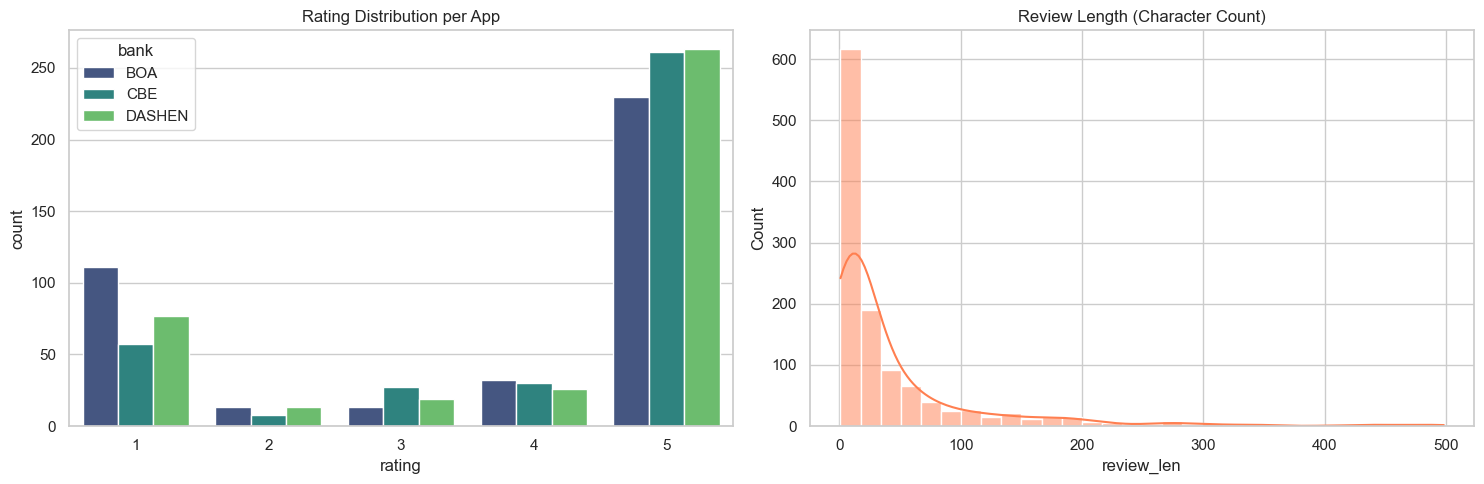

<Figure size 1100x500 with 0 Axes>

In [ ]:
# Visualizing Distributions
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Rating per App
df_clean = df.copy()

sns.countplot(data=df_clean, x='rating', hue='bank', palette='viridis', ax=ax[0])
ax[0].set_title('Rating Distribution per App')

df_clean['review_len'] = df_clean['review'].str.len()
sns.histplot(df_clean['review_len'], bins=30, kde=True, ax=ax[1], color='coral')
ax[1].set_title('Review Length (Character Count)')

plt.tight_layout()
plt.show()
ax[0].set_title('Rating Distribution per App')

# Review Length
df_clean['review_len'] = df_clean['review'].str.len()
sns.histplot(df_clean['review_len'], bins=30, kde=True, ax=ax[1], color='coral')
ax[1].set_title('Review Length (Character Count)')

plt.tight_layout(); plt.show()

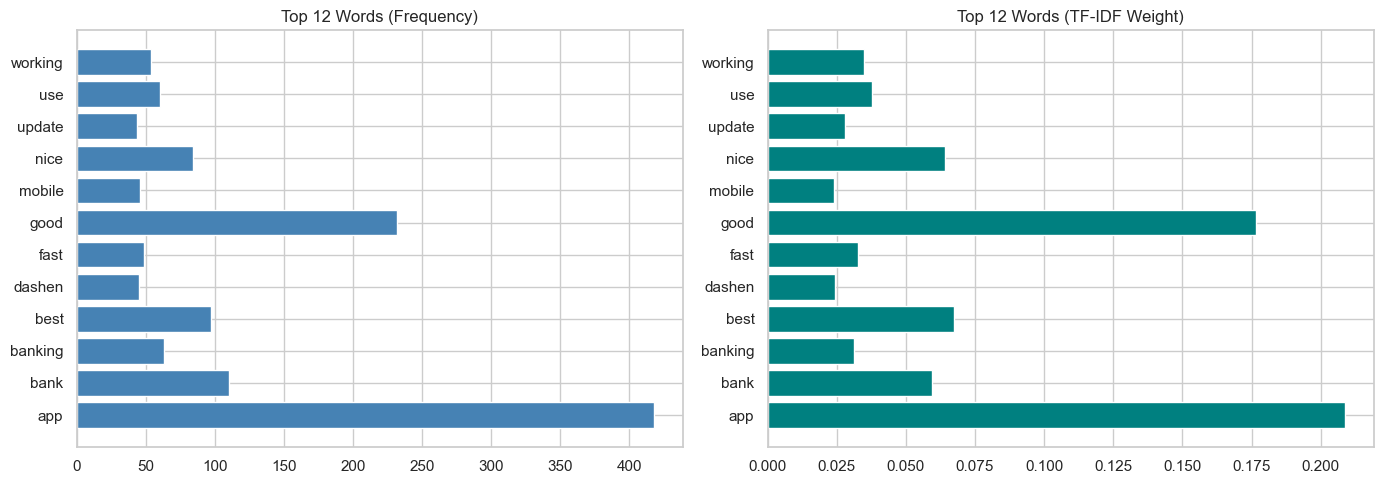

In [ ]:
# Frequency (BoW) vs TF-IDF
tfidf_vec = TfidfVectorizer(max_features=12, stop_words='english')
X_tfidf = tfidf_vec.fit_transform(df_clean['review'])

cv_vec = CountVectorizer(max_features=12, stop_words='english')
X_cv = cv_vec.fit_transform(df_clean['review'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(cv_vec.get_feature_names_out(), X_cv.toarray().sum(axis=0), color='steelblue')
axes[0].set_title('Top 12 Words (Frequency)')

axes[1].barh(tfidf_vec.get_feature_names_out(), X_tfidf.toarray().mean(axis=0), color='teal')
axes[1].set_title('Top 12 Words (TF-IDF Weight)')

plt.tight_layout()
plt.show()


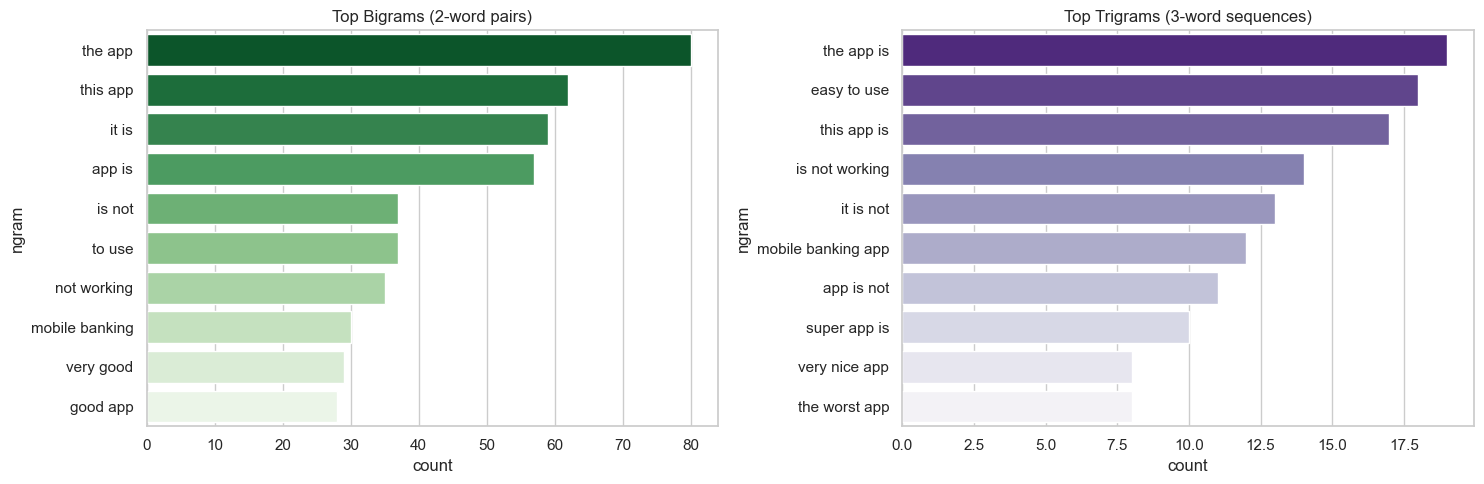

In [ ]:

def get_top_ngrams(corpus, n, k=10):
    vec = CountVectorizer(ngram_range=(n,n), max_features=100)
    X = vec.fit_transform(corpus)
    counts = X.sum(axis=0).A1
    return pd.DataFrame({'ngram': vec.get_feature_names_out(), 'count': counts}).sort_values('count', ascending=False).head(k)

bi = get_top_ngrams(df_clean['clean_text'], 2)
tri = get_top_ngrams(df_clean['clean_text'], 3)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=bi, x='count', y='ngram', ax=axes[0], palette='Greens_r')
axes[0].set_title('Top Bigrams (2-word pairs)')
sns.barplot(data=tri, x='count', y='ngram', ax=axes[1], palette='Purples_r')
axes[1].set_title('Top Trigrams (3-word sequences)')
plt.tight_layout(); plt.show()

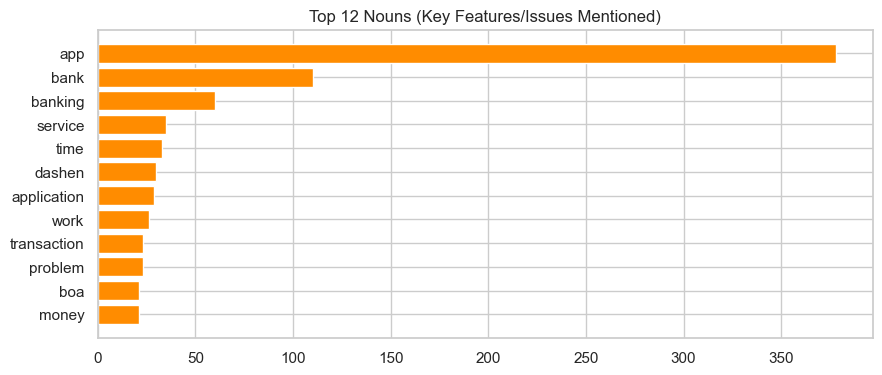

In [ ]:
# Identifying Product Features (Nouns)
import nltk
from nltk import word_tokenize, pos_tag
from collections import Counter
import matplotlib.pyplot as plt

# Download the specific tagger if it's not already downloaded
try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng', quiet=True)

def extract_nouns(text):
    tokens = word_tokenize(text)
    return [w.lower() for w, p in pos_tag(tokens) if p.startswith('NN') and len(w) > 2 and w.lower() not in stop_words]

# safer tokenizer to avoid missing 'punkt_tab' resource
def safe_extract_nouns(text):
    if not isinstance(text, str):
        return []
    tokens = re.findall(r"\b\w+\b", text.lower())
    return [w for w, p in pos_tag(tokens) if p.startswith('NN') and len(w) > 2 and w not in stop_words]

df_clean['nouns'] = df_clean['review'].apply(safe_extract_nouns)
all_nouns = [n for ns in df_clean['nouns'] for n in ns]
noun_counts = Counter(all_nouns).most_common(12)

plt.figure(figsize=(10, 4))
plt.barh([x[0] for x in noun_counts][::-1], [x[1] for x in noun_counts][::-1], color='darkorange')
plt.title('Top 12 Nouns (Key Features/Issues Mentioned)')
plt.show()

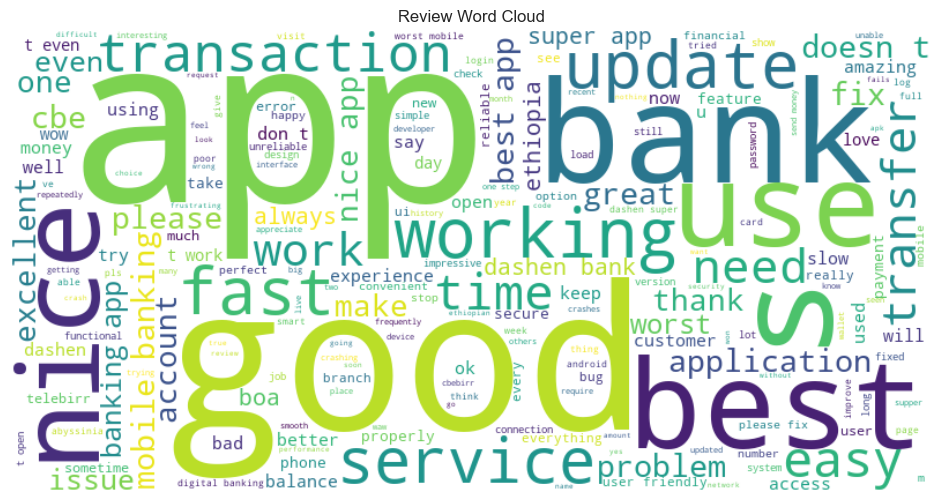

In [ ]:
#Word Cloud
text_combined = " ".join(df_clean['clean_text'])
wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text_combined)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Review Word Cloud')
plt.show()

In [ ]:
# Sentiment Application
df_clean['vader_compound'] = df_clean['review'].apply(lambda x: sia.polarity_scores(x)['compound'])
df_clean['tb_polarity'] = df_clean['review'].apply(lambda x: TextBlob(x).sentiment.polarity)
df_clean['tb_subjectivity'] = df_clean['review'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

def get_label(s):
    return 'positive' if s >= 0.05 else ('negative' if s <= -0.05 else 'neutral')

df_clean['sentiment'] = df_clean['vader_compound'].apply(get_label)
print("VADER Distribution:\n", df_clean['sentiment'].value_counts(normalize=True).round(2))

VADER Distribution:
 sentiment
positive    0.61
neutral     0.26
negative    0.13
Name: proportion, dtype: float64


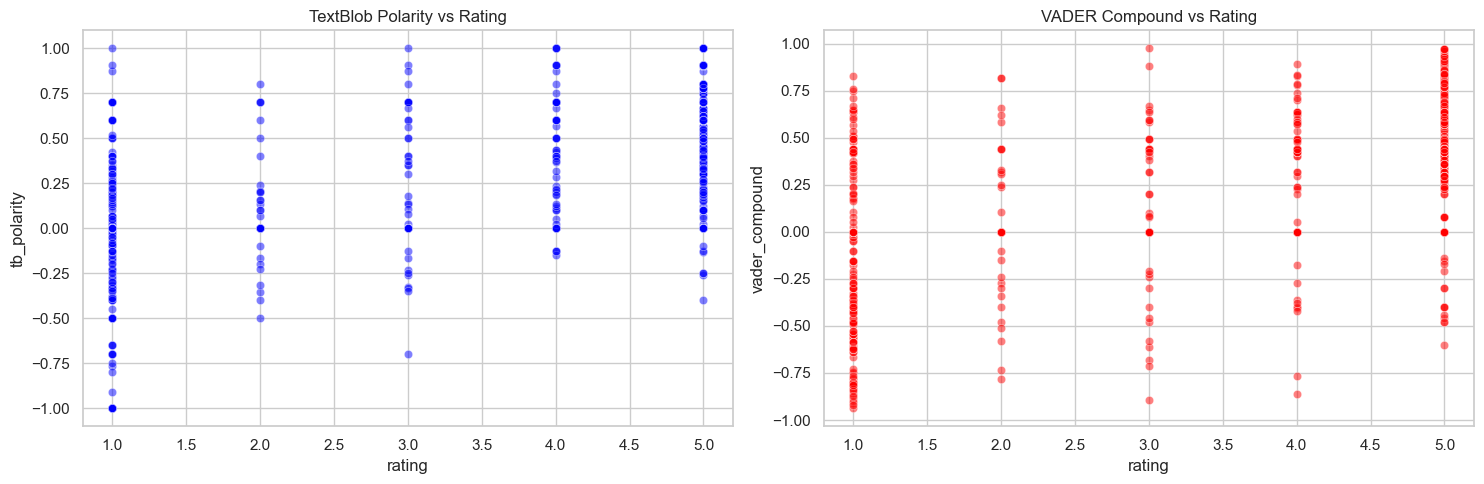

In [ ]:
# Sentiment vs. Star Rating
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# TextBlob Scatter
sns.scatterplot(data=df_clean, x='rating', y='tb_polarity', alpha=0.5, ax=axes[0], color='blue')
axes[0].set_title('TextBlob Polarity vs Rating')

# VADER Scatter
sns.scatterplot(data=df_clean, x='rating', y='vader_compound', alpha=0.5, ax=axes[1], color='red')
axes[1].set_title('VADER Compound vs Rating')

plt.tight_layout(); plt.show()

In [5]:
# Cell 11: Transformer Pipeline
from tqdm.notebook import tqdm

try:
    from transformers import pipeline
    sent_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

    # Apply transformer to all reviews in df_clean
    transformer_results = []
    # Process in batches to handle memory and speed, if df_clean is very large
    batch_size = 16 # Adjust batch size as needed
    for i in tqdm(range(0, len(df_clean), batch_size), desc="Running Transformer Sentiment"): # Changed desc here
        batch = df_clean['review'].iloc[i:i + batch_size].tolist()
        preds = sent_model(batch)
        transformer_results.extend(preds)

    df_clean['transformer_sentiment_label'] = [p['label'] for p in transformer_results]
    df_clean['transformer_sentiment_score'] = [p['score'] if p['label'] == 'POSITIVE' else -p['score'] for p in transformer_results]

    print("\nTransformer Sentiment Distribution:")
    print(df_clean['transformer_sentiment_label'].value_counts(normalize=True).round(2))

except Exception as e:
    print(f"Transformer skipped: {e}")

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Transformer skipped: name 'df_clean' is not defined


In [ ]:
# Cell 11.1: Visualizing Sentiment Score Correlation

# Ensure transformer_sentiment_score is available
if 'transformer_sentiment_score' not in df_clean.columns:
    print("Transformer sentiment scores not available for comparison.")
else:
    # Create a DataFrame for correlation
    sentiment_scores = df_clean[['vader_compound', 'tb_polarity', 'transformer_sentiment_score']]

    # Calculate the correlation matrix
    correlation_matrix = sentiment_scores.corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix of Sentiment Scores (VADER, TextBlob, Transformer)')
    plt.show()

    # Plotting scatter plots for pairwise comparison
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.scatterplot(data=df_clean, x='vader_compound', y='transformer_sentiment_score', alpha=0.5, ax=axes[0])
    axes[0].set_title('VADER Compound vs. Transformer Sentiment Score')
    axes[0].set_xlabel('VADER Compound Score')
    axes[0].set_ylabel('Transformer Sentiment Score')

    sns.scatterplot(data=df_clean, x='tb_polarity', y='transformer_sentiment_score', alpha=0.5, ax=axes[1])
    axes[1].set_title('TextBlob Polarity vs. Transformer Sentiment Score')
    axes[1].set_xlabel('TextBlob Polarity Score')
    axes[1].set_ylabel('Transformer Sentiment Score')

    plt.tight_layout()
    plt.show()